# Frequentist A/B Tests

## Overview

Frequentist A/B tests quantify whether an observed difference between two groups is consistent with chance under a null hypothesis. The result is a p-value and confidence interval — not a probability that the treatment works.

**Test selection by outcome type:**

| Outcome | Test | Assumption |
|---|---|---|
| Continuous, normal | Independent t-test | Equal or unequal variance |
| Continuous, non-normal | Mann-Whitney U | No distribution assumption |
| Binary | Chi-squared / proportions z-test | Large n |
| Binary, small n | Fisher exact | No large-n assumption |
| Paired (before/after) | Paired t-test | Differences normal |
| Multiple groups | One-way ANOVA → post-hoc | Homoscedasticity |

**Interpretation reminder:** p < 0.05 means "data are unlikely under H₀", not "treatment works with 95% probability".

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings; warnings.filterwarnings('ignore')

rng = np.random.default_rng(42)
n   = 60   # sites per group

# Simulate: restored vs control riparian sites
control   = rng.normal(15.0, 5.0, n)   # species richness
treatment = rng.normal(17.5, 5.2, n)   # ~2.5 species uplift
print(f"Control:   mean={control.mean():.2f}, sd={control.std():.2f}, n={n}")
print(f"Treatment: mean={treatment.mean():.2f}, sd={treatment.std():.2f}, n={n}")
print(f"Observed difference: {treatment.mean()-control.mean():.2f}")

Control:   mean=15.33, sd=3.90, n=60
Treatment: mean=16.53, sd=3.97, n=60
Observed difference: 1.21


---
## Independent Two-Sample t-test

Levene test for equal variance: F=0.019, p=0.892

Welch t-test:
  t = -1.665, df = 118.0, p = 0.0985
  Difference: 1.206  95% CI: [-0.216, 2.628]
  Fail to reject H0 at α=0.05
  Cohen's d = 0.307


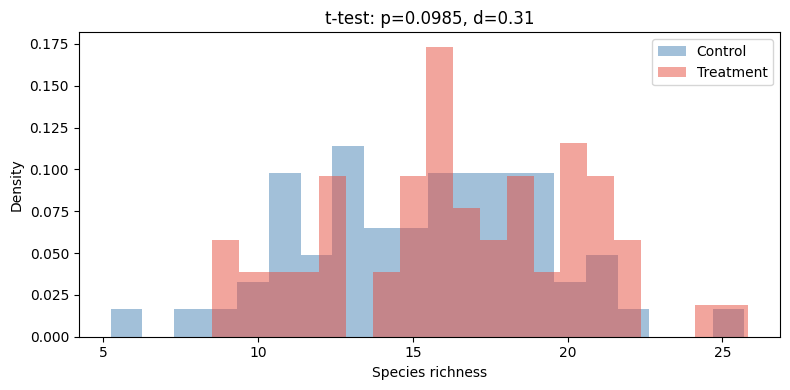

In [2]:
# Levene test for equal variance
lev_stat, lev_p = stats.levene(control, treatment)
print(f"Levene test for equal variance: F={lev_stat:.3f}, p={lev_p:.3f}")
equal_var = lev_p > 0.05

# t-test (Welch if variances unequal)
t_stat, p_val = stats.ttest_ind(control, treatment, equal_var=equal_var)
df_welch = (control.var()/n + treatment.var()/n)**2 /            ((control.var()/n)**2/(n-1) + (treatment.var()/n)**2/(n-1))
se_diff = np.sqrt(control.var()/n + treatment.var()/n)
diff    = treatment.mean() - control.mean()
ci_lo   = diff - stats.t.ppf(0.975, df_welch) * se_diff
ci_hi   = diff + stats.t.ppf(0.975, df_welch) * se_diff
print(f"\nWelch t-test:")
print(f"  t = {t_stat:.3f}, df = {df_welch:.1f}, p = {p_val:.4f}")
print(f"  Difference: {diff:.3f}  95% CI: [{ci_lo:.3f}, {ci_hi:.3f}]")
print(f"  {'Reject' if p_val < 0.05 else 'Fail to reject'} H0 at α=0.05")
# Effect size: Cohen's d
pooled_sd = np.sqrt(((n-1)*control.std()**2 + (n-1)*treatment.std()**2) / (2*n-2))
cohens_d  = diff / pooled_sd
print(f"  Cohen's d = {cohens_d:.3f}")
fig, ax = plt.subplots(figsize=(8,4))
ax.hist(control,   bins=20, alpha=0.5, color='steelblue', density=True, label='Control')
ax.hist(treatment, bins=20, alpha=0.5, color='#e74c3c',   density=True, label='Treatment')
ax.set_xlabel('Species richness'); ax.set_ylabel('Density')
ax.set_title(f't-test: p={p_val:.4f}, d={cohens_d:.2f}')
ax.legend(); plt.tight_layout(); plt.show()

---
## Mann-Whitney U and Proportions Test

In [3]:
# Non-parametric alternative: Mann-Whitney U
u_stat, mw_p = stats.mannwhitneyu(treatment, control, alternative='two-sided')
r_effect = u_stat / (n * n)   # rank-biserial correlation
print(f"Mann-Whitney U: U={u_stat:.1f}, p={mw_p:.4f}")
print(f"  Rank-biserial r = {r_effect:.3f}  (0.5=no effect, 1=complete separation)")

# Proportions test: fraction of sites exceeding richness target of 17
target = 17
p_ctrl = (control  > target).mean()
p_trt  = (treatment > target).mean()
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
count  = np.array([(treatment > target).sum(), (control > target).sum()])
nobs   = np.array([n, n])
z_stat, z_p = proportions_ztest(count, nobs)
ci_trt = proportion_confint((treatment > target).sum(), n, method='wilson')
ci_ctl = proportion_confint((control  > target).sum(), n, method='wilson')
print(f"\nProportions test (threshold={target}):")
print(f"  Control:   {p_ctrl:.3f}  95% CI: [{ci_ctl[0]:.3f}, {ci_ctl[1]:.3f}]")
print(f"  Treatment: {p_trt:.3f}  95% CI: [{ci_trt[0]:.3f}, {ci_trt[1]:.3f}]")
print(f"  z = {z_stat:.3f}, p = {z_p:.4f}")

Mann-Whitney U: U=2105.0, p=0.1100
  Rank-biserial r = 0.585  (0.5=no effect, 1=complete separation)

Proportions test (threshold=17):
  Control:   0.367  95% CI: [0.256, 0.493]
  Treatment: 0.450  95% CI: [0.331, 0.575]
  z = 0.929, p = 0.3531


---
## Paired t-test and Before/After Design

In [4]:
# Paired: same sites measured before and after restoration
before = rng.normal(13.0, 4.5, n)
uplift = rng.normal(2.5,  2.0, n)
after  = before + uplift
diff_pa = after - before
t_paired, p_paired = stats.ttest_rel(after, before)
se_paired = diff_pa.std() / np.sqrt(n)
ci_paired = stats.t.ppf(0.975, n-1) * se_paired
print(f"Paired t-test (before/after):")
print(f"  Mean difference: {diff_pa.mean():.3f}")
print(f"  95% CI: [{diff_pa.mean()-ci_paired:.3f}, {diff_pa.mean()+ci_paired:.3f}]")
print(f"  t={t_paired:.3f}, p={p_paired:.4f}")
print(f"  Cohen's d (paired): {diff_pa.mean()/diff_pa.std():.3f}")

# One-way ANOVA across 3 restoration intensities
grp_ctrl = rng.normal(15, 5, n)
grp_low  = rng.normal(17, 5, n)
grp_high = rng.normal(20, 5, n)
f_stat, anova_p = stats.f_oneway(grp_ctrl, grp_low, grp_high)
print(f"\nOne-way ANOVA (3 groups): F={f_stat:.3f}, p={anova_p:.4f}")
# Post-hoc Tukey HSD
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pandas as pd
data_long = np.concatenate([grp_ctrl, grp_low, grp_high])
groups    = ['control']*n + ['low']*n + ['high']*n
tukey = pairwise_tukeyhsd(data_long, groups, alpha=0.05)
print(tukey.summary())

Paired t-test (before/after):
  Mean difference: 2.465
  95% CI: [1.952, 2.977]
  t=9.534, p=0.0000
  Cohen's d (paired): 1.241

One-way ANOVA (3 groups): F=14.391, p=0.0000
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower  upper  reject
----------------------------------------------------
control   high   5.0236    0.0  2.8042  7.243   True
control    low   2.8367 0.0081  0.6173 5.0561   True
   high    low  -2.1869 0.0544 -4.4063 0.0325  False
----------------------------------------------------


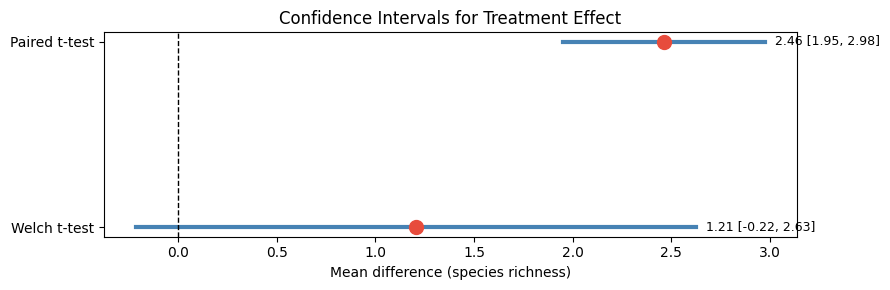

Confidence interval contains 0 -> not significant at α=0.05
Confidence interval excludes 0 -> significant at α=0.05


In [5]:
# Confidence interval forest plot
tests = {
    'Welch t-test':     (diff, ci_lo, ci_hi),
    'Paired t-test':    (diff_pa.mean(),
                         diff_pa.mean()-ci_paired, diff_pa.mean()+ci_paired),
}
fig, ax = plt.subplots(figsize=(9,3))
for i, (name, (est, lo, hi)) in enumerate(tests.items()):
    ax.plot([lo, hi], [i, i], '-', color='steelblue', lw=3)
    ax.plot(est, i, 'o', color='#e74c3c', ms=10, zorder=3)
    ax.text(hi+0.05, i, f'{est:.2f} [{lo:.2f}, {hi:.2f}]', va='center', fontsize=9)
ax.axvline(0, color='black', lw=1, linestyle='--')
ax.set_yticks(range(len(tests))); ax.set_yticklabels(list(tests.keys()))
ax.set_xlabel('Mean difference (species richness)')
ax.set_title('Confidence Intervals for Treatment Effect')
plt.tight_layout(); plt.show()
print("Confidence interval contains 0 -> not significant at α=0.05")
print("Confidence interval excludes 0 -> significant at α=0.05")

---

## Common Pitfalls

**1. Interpreting p < 0.05 as "the effect is real" or p > 0.05 as "no effect"**  
The p-value is the probability of data as extreme as observed if H₀ is true — not the probability that H₀ is true. A non-significant result means the data are consistent with zero effect, not that the effect is zero. Always report the confidence interval to quantify the range of plausible effect sizes.

**2. Using an independent t-test when observations are paired**  
Paired designs (before/after, matched sites) have correlated observations. Using an independent t-test ignores the within-pair correlation, inflating the standard error and reducing power. The paired t-test removes between-pair variability and is substantially more powerful for paired data.

**3. Not checking the equal-variance assumption before selecting a t-test**  
Student's t-test assumes equal variances; Welch's t-test does not. Welch's test has only marginally lower power when variances are equal but is substantially more accurate when they differ. Use Levene's test first and default to Welch's unless variances are clearly equal.

**4. Running multiple pairwise t-tests after a significant ANOVA without correction**  
After finding a significant omnibus ANOVA, running all pairwise t-tests without multiplicity correction inflates the family-wise error rate. Use Tukey HSD (for all pairwise comparisons) or Dunnett's test (for comparisons against a control) as the planned post-hoc procedure.

**5. Reporting only p-values without effect size and confidence interval**  
A statistically significant result with p = 0.001 may correspond to a trivially small effect size (e.g. Cohen's d = 0.05) in a large study. Always report Cohen's d (continuous) or relative risk / odds ratio (binary) alongside the p-value and confidence interval so readers can assess practical significance.

---
*python_methods_library - Samantha McGarrigle*